# Drift Evaluation: HTC Vive Tracker vs Robot End-Effector

This notebook evaluates the **absolute distance** between:
- **src** = HTC Vive tracker (mounted on HMD)
- **ee** = robot end-effector

**Goal:** Measure drift after moving around the room with the HMD on the head.
- Distance at **start** (first sample per run)
- Distance at **end** (last sample per run)
- **Drift** = change in distance over the session

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

In [2]:
# --- Configuration ---
# Path to CalibrationLogs (Data type A: experiment samples with src_p*, ee_p* columns)
CALIBRATION_LOGS_PATH = Path("./CalibrationLogs")

# Alternative: use existing data folder (matrix_Source + matrix_Transformed/Hand_Source)
DATA_BASE_PATH = Path("./data")

# Expected columns for Data type A (experiment samples)
SRC_COLS = ["src_px", "src_py", "src_pz"]
EE_COLS = ["ee_px", "ee_py", "ee_pz"]

In [3]:
def load_samples_calibration_logs(base_path: Path) -> pd.DataFrame | None:
    """Load Data type A from CalibrationLogs (samples with run_id, src_p*, ee_p*)."""
    candidates = [
        base_path / "samples.csv",
        base_path / "experiment_samples.csv",
        base_path / "correspondence_pairs.csv",
    ]
    for p in candidates:
        if p.exists():
            df = pd.read_csv(p)
            if "run_id" in df.columns and "src_px" in df.columns and "ee_px" in df.columns:
                return df
    return None


def load_samples_legacy(data_base: Path) -> pd.DataFrame | None:
    """Fallback: load from existing *Calibration folders (matrix_Demonstrator_Source + matrix_Hand_Source)."""
    rows = []
    for exp_group in sorted(data_base.iterdir()):
        if not exp_group.is_dir():
            continue
        for calib_dir in exp_group.rglob("*"):
            if not calib_dir.is_dir() or not calib_dir.name.endswith("Calibration"):
                continue
            src_file = calib_dir / "matrix_Demonstrator_Source.csv"
            if not src_file.exists():
                continue
            ee_file = calib_dir / "matrix_Hand_Source.csv"
            if not ee_file.exists():
                ee_file = calib_dir / "matrix_Demonstrator_Transformed.csv"
            if not ee_file.exists():
                continue
            src_arr = np.loadtxt(src_file, delimiter=",")
            ee_arr = np.loadtxt(ee_file, delimiter=",")
            n = min(len(src_arr), len(ee_arr))
            run_id = f"{exp_group.name}_{calib_dir.name}"
            for i in range(n):
                rows.append({
                    "run_id": run_id,
                    "src_px": src_arr[i, 0], "src_py": src_arr[i, 1], "src_pz": src_arr[i, 2],
                    "ee_px": ee_arr[i, 0], "ee_py": ee_arr[i, 1], "ee_pz": ee_arr[i, 2],
                })
    return pd.DataFrame(rows) if rows else None


if CALIBRATION_LOGS_PATH.exists():
    samples = load_samples_calibration_logs(CALIBRATION_LOGS_PATH)
else:
    samples = None

if samples is None and DATA_BASE_PATH.exists():
    samples = load_samples_legacy(DATA_BASE_PATH)

if samples is None:
    raise FileNotFoundError(
        "No sample data found. Either create ./CalibrationLogs/ with samples.csv (Data type A schema) "
        "or ensure ./data/ has *Calibration folders with matrix_Demonstrator_Source.csv and matrix_Hand_Source.csv."
    )

print(f"Loaded {len(samples)} samples across {samples['run_id'].nunique()} runs")
samples.head()

Loaded 21400 samples across 428 runs


,run_id,src_px,src_py,src_pz,ee_px,ee_py,ee_pz
0,experiment_0_2Hz_2025-12-12_14-47-57-Calibration,2.032574,3.055770,1.513515,-3.810980,1.491287,1.408858
1,experiment_0_2Hz_2025-12-12_14-47-57-Calibration,2.059731,3.037279,1.541202,-3.775797,1.522371,1.414729
2,experiment_0_2Hz_2025-12-12_14-47-57-Calibration,2.091185,3.011363,1.557020,-3.739756,1.544498,1.429657
3,experiment_0_2Hz_2025-12-12_14-47-57-Calibration,2.120202,2.985688,1.554298,-3.703768,1.541553,1.442596
4,experiment_0_2Hz_2025-12-12_14-47-57-Calibration,2.147473,2.966066,1.549899,-3.669557,1.533465,1.438741


In [4]:
def euclidean_distance(df: pd.DataFrame, src_cols: list, ee_cols: list) -> np.ndarray:
    """Compute per-sample Euclidean distance between src and ee positions."""
    src = df[src_cols].values
    ee = df[ee_cols].values
    return np.linalg.norm(src - ee, axis=1)


# Compute distance for each sample
samples["distance_m"] = euclidean_distance(samples, SRC_COLS, EE_COLS)
print("Sample distances (first 10):", samples["distance_m"].head(10).values)
print("Distance stats (m): mean={:.4f}, std={:.4f}".format(samples["distance_m"].mean(), samples["distance_m"].std()))

Sample distances (first 10): [6.05026309 6.0302843  6.01396601 6.00138566 5.99187281 5.986527
 5.9855256  5.97319413 5.96513024 5.95716925]
Distance stats (m): mean=2.8421, std=0.7076


In [5]:
# Per run: distance at START (first sample) and END (last sample)
def compute_drift_per_run(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby("run_id", sort=False)
    results = []
    for run_id, grp in grouped:
        grp = grp.sort_values("timestamp_ms") if "timestamp_ms" in grp.columns else grp.reset_index(drop=True)
        start_dist = grp["distance_m"].iloc[0]
        end_dist = grp["distance_m"].iloc[-1]
        drift = end_dist - start_dist
        n = len(grp)
        results.append({
            "run_id": run_id,
            "n_samples": n,
            "distance_start_m": start_dist,
            "distance_end_m": end_dist,
            "drift_m": drift,
        })
    return pd.DataFrame(results)


drift_df = compute_drift_per_run(samples)
drift_df

,run_id,n_samples,distance_start_m,distance_end_m,drift_m
0,experiment_0_2Hz_2025-12-12_14-47-57-Calibration,50,6.050263,5.711795,-0.338468
1,experiment_0_2Hz_2025-12-12_14-48-02-Calibration,50,5.755282,5.803333,0.048051
2,experiment_0_2Hz_2025-12-12_14-48-07-Calibration,50,5.855446,5.860530,0.005084
3,experiment_0_2Hz_2025-12-12_14-48-12-Calibration,50,5.852690,5.524036,-0.328654
4,experiment_0_2Hz_2025-12-12_14-48-17-Calibration,50,5.552854,5.958843,0.405989
...,...,...,...,...,...
423,experiment_5Hz_2025-12-19_09-38-33-Calibration,50,2.796979,2.876930,0.079951
424,experiment_5Hz_2025-12-19_09-38-34-Calibration,50,2.927756,2.869466,-0.058290
425,experiment_5Hz_2025-12-19_09-38-35-Calibration,50,2.947184,2.874211,-0.072973
426,experiment_5Hz_2025-12-19_09-38-36-Calibration,50,2.852673,2.876888,0.024215


In [6]:
# --- Summary statistics ---
print("=" * 60)
print("DRIFT SUMMARY (distance change: end - start)")
print("=" * 60)
print(f"Runs: {len(drift_df)}")
print(f"Mean distance at start (m): {drift_df['distance_start_m'].mean():.4f}")
print(f"Mean distance at end (m):   {drift_df['distance_end_m'].mean():.4f}")
print(f"Mean drift (m):             {drift_df['drift_m'].mean():.4f}")
print(f"Std drift (m):              {drift_df['drift_m'].std():.4f}")
print(f"Max absolute drift (m):     {drift_df['drift_m'].abs().max():.4f}")
print("=" * 60)

DRIFT SUMMARY (distance change: end - start)
Runs: 428
Mean distance at start (m): 2.8528
Mean distance at end (m):   2.8520
Mean drift (m):             -0.0008
Std drift (m):              0.3120
Max absolute drift (m):     1.7953


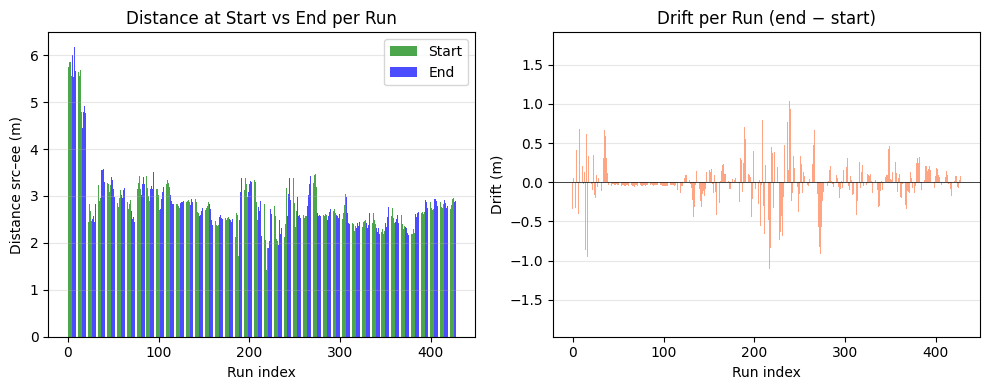

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: Start vs End distance per run
ax = axes[0]
runs = range(len(drift_df))
ax.bar([r - 0.2 for r in runs], drift_df["distance_start_m"], 0.4, label="Start", color="green", alpha=0.7)
ax.bar([r + 0.2 for r in runs], drift_df["distance_end_m"], 0.4, label="End", color="blue", alpha=0.7)
ax.set_xlabel("Run index")
ax.set_ylabel("Distance src–ee (m)")
ax.set_title("Distance at Start vs End per Run")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Right: Drift distribution
ax = axes[1]
ax.bar(runs, drift_df["drift_m"], color="coral", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Run index")
ax.set_ylabel("Drift (m)")
ax.set_title("Drift per Run (end − start)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()